# COMP0005 - GROUP COURSEWORK
# Experimental Evaluation of Search Data Structures and Algorithms

The cell below defines **AbstractSearchInterface**, an interface to support basic insert/search operations; you will need to implement this three times, to realise your three search data structures of choice among: (1) *2-3 Tree*, (2) *AVL Tree*, (3) *LLRB BST*; (4) *B-Tree*; and (5) *Scapegoat Tree*. <br><br>**Do NOT modify the next cell** - use the dedicated cells further below for your implementation instead. <br>

In [1]:
# DO NOT MODIFY THIS CELL

from abc import ABC, abstractmethod  

class AbstractSearchInterface(ABC):
    '''
    Abstract class to support search/insert operations (plus underlying data structure)
    
    '''
        
    @abstractmethod
    def insertElement(self, element) -> 'bool|None':
        '''
        Insert an element in a search tree
            Parameters:
                    element: string to be inserted in the search tree (string)

            Returns:
                    "True" after successful insertion, "False" if element is already present (bool)
        '''
        
        pass 
    

    @abstractmethod
    def searchElement(self, element) -> bool:
        '''
        Search for an element in a search tree
            Parameters:
                    element: string to be searched in the search tree (string)

            Returns:
                    "True" if element is found, "False" otherwise (bool)
        '''

        pass

Use the cell below to define any auxiliary data structure and python function you may need. Leave the implementation of the main API to the next code cells instead.

In [2]:
# ADD AUXILIARY DATA STRUCTURE DEFINITIONS AND HELPER CODE HERE



Use the cell below to implement the requested API by means of **2-3 Tree** (if among your chosen data structure).

In [3]:
class TwoThreeTree(AbstractSearchInterface):
    
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found    

Use the cell below to implement the requested API by means of **AVL Tree** (if among your chosen data structure).

In [4]:
class AVLTree(AbstractSearchInterface):
    
    class Node():
        
        def __init__(self,value):
            self.value:str = value
            self.left: 'AVLTree.Node | None' = None
            self.right: 'AVLTree.Node | None' = None
            self.height: int = 1

        def set_height(self):
            self.height = max(self.get_height(self.left),self.get_height(self.right))+1

        @staticmethod
        def get_height(node) -> int:
            return node.height if node else 0 

    def __init__(self, root=None):
        self.root = root
            
    def height(self):
        assert self.root is not None
        return self.root.height
    

    @staticmethod
    def rotate_left(node:'AVLTree.Node') -> 'AVLTree.Node':
        '''Rotate the subtree with root `node` to the left and return the root of the subtree (new or unchanged)'''
        
        assert node.right is not None # When a subtree is rotated left it should have a right Node

        root: AVLTree.Node = node.right
        node.right = root.left
        root.left = node

        node.set_height()
        root.set_height()

        return root
    
    @staticmethod
    def rotate_right(node:'AVLTree.Node') -> 'AVLTree.Node':
        '''Rotate the subtree with root `node` to the right, and return the root of the subtree (new or unchanged)'''
        assert node.left is not None

        root: AVLTree.Node = node.left
        node.left = root.right
        root.right = node

        node.set_height()
        root.set_height()

        return root

    @staticmethod
    def rebalance(node:'AVLTree.Node') -> 'AVLTree.Node':
        '''Rebalance the subtree with root `node`'''
        imbalance:int = AVLTree.Node.get_height(node.right) - AVLTree.Node.get_height(node.left)
        
        if imbalance > 1: # Right Imbalance
            assert node.right is not None

            if AVLTree.Node.get_height(node.right.right) >= AVLTree.Node.get_height(node.right.left):
                # RR - so single left rotation to balance
                node = AVLTree.rotate_left(node)
            else:
                # RL - so double rotation (Right/Left) to balance
                node.right = AVLTree.rotate_right(node.right)
                node = AVLTree.rotate_left(node)
        elif imbalance < -1:
            assert node.left is not None

            if AVLTree.Node.get_height(node.left.left) >= AVLTree.Node.get_height(node.left.right):
                # LL - so single right rotation to balance
                node = AVLTree.rotate_right(node)
            else:
                # LR - so double rotation (Left/Right) to balance
                node.left = AVLTree.rotate_left(node.left)
                node = AVLTree.rotate_right(node)

        return node

    @staticmethod                
    def _insert(node:'AVLTree.Node | None', value:str) -> 'AVLTree.Node':
        '''Recursive helper function to insert a node into an AVL Tree'''
        if node is None:
            return AVLTree.Node(value)
        if value < node.value:
            node.left = AVLTree._insert(node.left, value)
        elif value > node.value:
            node.right = AVLTree._insert(node.right, value)
        else:
            raise ValueError(f"Duplicate value: {value}")

        AVLTree.Node.set_height(node)
        node = AVLTree.rebalance(node)
        
        return node
    
    @staticmethod
    def _search(node:'AVLTree.Node | None',value:str) -> bool:
        '''recursive search function to search for a value in an AVL Tree'''
        if node is None:
            return False
        if value < node.value:
            return AVLTree._search(node.left,value)
        elif value > node.value:
            return AVLTree._search(node.right,value)
        else:
            return True
        


    def insertElement(self, element):
        try:
            self.root = AVLTree._insert(self.root, element)
            return True
        except ValueError:
            return False
    

    def searchElement(self, element):     
        return AVLTree._search(self.root,element)

Use the cell below to implement the requested API by means of **LLRB BST** (if among your chosen data structure).

In [5]:
class Node:
    
    def __init__(self, value):
        self.value = value
        self.colour = "red"
        self.left = None
        self.right = None


class LLRBBST(AbstractSearchInterface):

    
    def __init__(self):
        self.root = None

    #helpers 
    @staticmethod
    def rotate_left(n):
        x = n.right
        n.right = x.left
        x.left = n
        x.colour = n.colour
        n.colour = "red"

        return x

    @staticmethod
    def rotate_right(n):
        x = n.left
        n.left = x.right
        x.right = n
        x.colour = n.colour
        n.colour = "red"

        return x

    @staticmethod
    def colour_flip(n):
        n.colour = "red"
        n.left.colour = "black"
        n.right.colour = "black"

    @staticmethod
    def is_red(n):
        if n is None:
            return False
        return n.colour == "red"

        
    def insertElement(self, element):
        # ADD YOUR CODE HERE
        self.root, inserted = LLRBBST._insert(self.root, element)
        self.root.colour = "black"
        
        return inserted
    
    @staticmethod
    def _insert(root, element):
        if root is None:
            return Node(element), True

        if element < root.value:
            root.left, inserted = LLRBBST._insert(root.left, element)
        elif element > root.value:
            root.right, inserted = LLRBBST._insert(root.right, element)
        else:
            return root, False   # duplicate found

        if LLRBBST.is_red(root.right) and not LLRBBST.is_red(root.left):
            root = LLRBBST.rotate_left(root)
        if LLRBBST.is_red(root.left) and LLRBBST.is_red(root.left.left):
            root = LLRBBST.rotate_right(root)
        if LLRBBST.is_red(root.left) and LLRBBST.is_red(root.right):
            LLRBBST.colour_flip(root)

        return root, inserted
    
    
    @staticmethod
    def _search(node, target):
        if node is None:
            return False
        elif node.value == target:
            return True
        elif target > node.value: 
            return LLRBBST._search(node.right, target)
        else:
            return LLRBBST._search(node.left, target)


    def searchElement(self, element):     
        return LLRBBST._search(self.root, element)
    


Use the cell below to implement the requested API by means of **B-Tree** (if among your chosen data structure).

In [6]:
class BTree(AbstractSearchInterface):
        
    def insertElement(self, element):
        inserted = False
        # ADD YOUR CODE HERE
      
        
        return inserted
    
    

    def searchElement(self, element):     
        found = False
        # ADD YOUR CODE HERE

        
        return found

Use the cell below to implement the requested API by means of **Scapegoat Tree** (if among your chosen data structure).

In [7]:
class ScapegoatTree(AbstractSearchInterface):
        
    class _Node:
        def __init__(self, key):
            self.key = key
            self.left = None
            self.right = None
            self.size = 1

    def __init__(self, alpha=0.7):
        # alpha controls how imbalanced a node may become before rebuilding its subtree.
        # A valid scapegoat alpha is in (0.5, 1). If an invalid value is given, we fall back to 0.7.
        if isinstance(alpha, (int, float)) and 0.5 < float(alpha) < 1.0:
            self.alpha = float(alpha)
        else:
            self.alpha = 0.7
        self.root = None
        self.n = 0  # current number of elements
        self.q = 0  # historical upper bound used by scapegoat criterion

    def _size(self, node):
        return node.size if node is not None else 0

    def _update_size(self, node):
        if node is not None:
            node.size = 1 + self._size(node.left) + self._size(node.right)

    def _log_alpha_inverse(self, value):
        if value <= 1:
            return 0

        # Compute ceil(log_{1/alpha}(value)) using only arithmetic.
        # Since 0.5 < alpha < 1, dividing by alpha multiplies by (1/alpha) > 1.
        threshold = 1.0
        height_bound = 0
        while threshold < value:
            threshold /= self.alpha
            height_bound += 1
        return height_bound

    def _is_unbalanced(self, node):
        if node is None:
            return False
        left_size = self._size(node.left)
        right_size = self._size(node.right)
        return max(left_size, right_size) > self.alpha * self._size(node)

    def _inorder_collect_nodes(self, node, nodes):
        if node is None:
            return
        self._inorder_collect_nodes(node.left, nodes)
        nodes.append(node)
        self._inorder_collect_nodes(node.right, nodes)

    def _build_balanced_from_sorted_nodes(self, nodes, left_index, right_index):
        if left_index > right_index:
            return None

        mid = (left_index + right_index) // 2
        root = nodes[mid]

        root.left = self._build_balanced_from_sorted_nodes(nodes, left_index, mid - 1)
        root.right = self._build_balanced_from_sorted_nodes(nodes, mid + 1, right_index)
        self._update_size(root)
        return root

    def _rebuild_subtree(self, subtree_root):
        nodes = []
        self._inorder_collect_nodes(subtree_root, nodes)
        return self._build_balanced_from_sorted_nodes(nodes, 0, len(nodes) - 1)

    def insertElement(self, element):
        inserted = False

        # Scapegoat Tree insertion works in two phases:
        # (1) Insert like a normal BST while tracking the root->leaf path and updating subtree sizes.
        # (2) If depth is too large (greater than log_{1/alpha}(q)), find the first ancestor that is
        #     alpha-unbalanced (the scapegoat), rebuild only that subtree into a perfectly balanced BST,
        #     and reattach it to its parent. This keeps amortized insertion efficient.

        # Edge-case handling: only non-empty strings are accepted.
        if not isinstance(element, str) or element == "":
            return inserted

        # Empty tree case.
        if self.root is None:
            self.root = self._Node(element)
            self.n = 1
            self.q = 1
            inserted = True
            return inserted

        path = []
        current = self.root

        while current is not None:
            path.append(current)
            if element == current.key:
                # Duplicate key: no insertion.
                return inserted
            if element < current.key:
                if current.left is None:
                    current.left = self._Node(element)
                    path.append(current.left)
                    inserted = True
                    break
                current = current.left
            else:
                if current.right is None:
                    current.right = self._Node(element)
                    path.append(current.right)
                    inserted = True
                    break
                current = current.right

        if not inserted:
            return inserted

        self.n += 1
        if self.n > self.q:
            self.q = self.n

        # Update sizes from inserted node back to root.
        for node in reversed(path[:-1]):
            self._update_size(node)

        # Depth of inserted node is number of edges from root.
        depth = len(path) - 1

        # Check scapegoat criterion.
        if depth > self._log_alpha_inverse(self.q):
            scapegoat_index = None

            # Walk upwards (excluding inserted leaf itself) and find first unbalanced ancestor.
            for idx in range(len(path) - 2, -1, -1):
                node = path[idx]
                if self._is_unbalanced(node):
                    scapegoat_index = idx
                    break

            if scapegoat_index is not None:
                scapegoat = path[scapegoat_index]
                rebuilt = self._rebuild_subtree(scapegoat)

                if scapegoat_index == 0:
                    # Rebuilt subtree becomes whole-tree root.
                    self.root = rebuilt
                else:
                    parent = path[scapegoat_index - 1]
                    if parent.left is scapegoat:
                        parent.left = rebuilt
                    else:
                        parent.right = rebuilt

                    # Recompute sizes on ancestors above parent.
                    for idx in range(scapegoat_index - 1, -1, -1):
                        self._update_size(path[idx])

        return inserted
    
    

    def searchElement(self, element):     
        found = False
        

        # Edge-case handling: reject non-string and empty-string search keys.
        if not isinstance(element, str) or element == "":
            return found

        current = self.root
        while current is not None:
            if element == current.key:
                found = True
                break
            if element < current.key:
                current = current.left
            else:
                current = current.right

        
        return found 

Use the cell below to implement the **synthetic data generator** needed by your experimental framework (be mindful of code readability and reusability).

In [8]:
import string
import random

class TestDataGenerator():
    '''
    A class to represent a synthetic data generator.

    ...

    Attributes
    ----------
    
    seed : int
        Random seed for reproducibility of data generation.


    Methods
    -------
    
    generate_random_strings(dataset_size)
        Generates a list of random 10-character lowercase strings in random order.

    generate_sorted_random_strings(dataset_size)
        Generates a list of random 10-character lowercase strings in alphabetical order.

    generate_reverse_sorted_random_strings(dataset_size)
        Generates a list of random 10-character lowercase strings in reverse alphabetical order.

    generate_successful_search_data(dataset, sample_size)
        Returns a random sample of strings from a given dataset for successful search testing.

    generate_unsuccessful_search_data(sample_size)
        Generates 11-character lowercase strings guaranteed not to exist in any 10-character dataset for unsuccessful search testing.

    '''
    
    #ADD YOUR CODE HERE

    def __init__(self, seed):
        self.seed = seed
        random.seed(seed)
    
    def generate_random_strings(self, dataset_size):
        random_dataset = []
        for i in range(dataset_size):
            entry = ''.join(random.choices(string.ascii_lowercase, k=10))
            random_dataset.append(entry)
        return random_dataset
        
    def generate_sorted_random_strings(self, dataset_size):
        random_set = self.generate_random_strings(dataset_size)
        sorted_dataset = sorted(random_set)
        return sorted_dataset

    def generate_reverse_sorted_random_strings(self, dataset_size):
        random_set = self.generate_random_strings(dataset_size)
        reverse_sorted_dataset = sorted(random_set, reverse=True)
        return reverse_sorted_dataset
    
    def generate_successful_search_data(self, dataset, sample_size):
        successful_search_sample = random.choices(dataset, k=sample_size)
        return successful_search_sample

    def generate_unsuccessful_search_data(self, sample_size):
        unsuccessful_search_sample = []
        for i in range(sample_size):
            entry = ''.join(random.choices(string.ascii_lowercase, k=11))
            unsuccessful_search_sample.append(entry)
        return unsuccessful_search_sample 
    

Use the cell below to implement the requested **experimental framework** (be mindful of code readability and reusability).

In [9]:
import timeit
import matplotlib.pyplot as plt

class ExperimentalFramework():
    '''
    A class to represent an experimental framework.

    Attributes
    ----------
    SIZE : dict
        Dataset sizes - S=10000, M=100000, L=1000000
    SIZE_LABELS : dict
        Human-readable labels for sizes
    ORDEREDNESS : list
        Input data orderings: random, sorted, reverse-sorted, zig-zag, repeated-values
    SEARCH_DATA_PRESENT_RATE : list
        Proportion of searches that target existing elements
    READ_WRITE_RATIO : list
        Number of reads as a proportion of writes

    Methods
    -------
    run_test(tree, ...) -> dict
        Run a single experiment with given parameters.
    run_full_evaluation(trees, num_trials) -> list[dict]
        Run all experiments across all parameter variations and trees, averaging over trials.
    plot_full_evaluation(results)
        Plot bar charts for each varied parameter.
    '''

    SIZE = {"S": 10000, "M": 100000, "L": 1000000}
    SIZE_LABELS = {"S": "Small (10K)", "M": "Medium (100K)", "L": "Large (1M)"}
    ORDEREDNESS = ["random", "sorted", "reverse-sorted", "zig-zag", "repeated-values"]
    SEARCH_DATA_PRESENT_RATE = [0, 0.25, 0.50, 0.75, 1]
    READ_WRITE_RATIO = [0, 0.5, 1, 2, 5, 10]

    DEFAULTS = {
        "size": "M",
        "orderedness": "random",
        "search_data_present_rate": 0.75,
        "read_write_ratio": 1
    }

    def __init__(self):
        pass

    def _generate_dataset(self, generator, size_key, orderedness):
        """Generate a dataset of the given size and orderedness."""
        n = self.SIZE[size_key]

        if orderedness == "random":
            return generator.generate_random_strings(n)
        elif orderedness == "sorted":
            return generator.generate_sorted_random_strings(n)
        elif orderedness == "reverse-sorted":
            return generator.generate_reverse_sorted_random_strings(n)
        elif orderedness == "zig-zag":
            sorted_data = generator.generate_sorted_random_strings(n)
            half = len(sorted_data) // 2
            first_half = sorted_data[:half]
            second_half = sorted_data[half:][::-1]
            dataset = []
            for a, b in zip(first_half, second_half):
                dataset.append(a)
                dataset.append(b)
            # If odd length, append the remaining element
            if len(first_half) < len(second_half):
                dataset.append(second_half[-1])
            elif len(second_half) < len(first_half):
                dataset.append(first_half[-1])
            return dataset
        elif orderedness == "repeated-values":
            unique_count = max(1, n // 3)
            unique_data = generator.generate_random_strings(unique_count)
            dataset = (unique_data * 3)[:n]
            random.shuffle(dataset)
            return dataset
        else:
            raise ValueError(f"Unknown orderedness: {orderedness}")

    def run_test(self, tree, size=None, orderedness=None, search_data_present_rate=None, read_write_ratio=None):
        """Run a single experiment and return timing results."""
        size = size if size is not None else self.DEFAULTS["size"]
        orderedness = orderedness if orderedness is not None else self.DEFAULTS["orderedness"]
        search_data_present_rate = search_data_present_rate if search_data_present_rate is not None else self.DEFAULTS["search_data_present_rate"]
        read_write_ratio = read_write_ratio if read_write_ratio is not None else self.DEFAULTS["read_write_ratio"]

        if size not in self.SIZE:
            raise ValueError(f"Invalid size: {size}")
        if orderedness not in self.ORDEREDNESS:
            raise ValueError(f"Invalid orderedness: {orderedness}")

        generator = TestDataGenerator(seed=42)
        dataset = self._generate_dataset(generator, size, orderedness)

        # Generate search queries
        search_count = int(self.SIZE[size] * read_write_ratio)
        num_successful = int(search_count * search_data_present_rate)
        num_unsuccessful = search_count - num_successful

        search_data = []
        if num_successful > 0:
            search_data += generator.generate_successful_search_data(dataset, num_successful)
        if num_unsuccessful > 0:
            search_data += generator.generate_unsuccessful_search_data(num_unsuccessful)
        random.shuffle(search_data)

        # Insert phase
        test_tree = tree()
        insert_start = timeit.default_timer()
        for element in dataset:
            test_tree.insertElement(element)
        insert_time = timeit.default_timer() - insert_start

        # Search phase
        search_start = timeit.default_timer()
        for element in search_data:
            test_tree.searchElement(element)
        search_time = timeit.default_timer() - search_start
       
        overall_time = insert_time + search_time

        return {
            "insert_time": insert_time,
            "search_time": search_time,
            "overall_time": overall_time,
            "size": size,
            "orderedness": orderedness,
            "search_data_present_rate": search_data_present_rate,
            "read_write_ratio": read_write_ratio
        }

    def run_full_evaluation(self, trees, num_trials=5):
        """
        Run experiments varying each parameter independently (others held at defaults).
        Each configuration is repeated num_trials times and results are averaged.
        """
        results = []

        # Define the parameter sweeps: (param_name, list_of_values)
        sweeps = [
            ("size", list(self.SIZE.keys())),
            ("orderedness", self.ORDEREDNESS),
            ("search_data_present_rate", self.SEARCH_DATA_PRESENT_RATE),
            ("read_write_ratio", self.READ_WRITE_RATIO),
        ]

        total = sum(len(vals) for _, vals in sweeps) * len(trees) * num_trials
        done = 0

        for tree_name, tree_class in trees.items():
            for param_name, param_values in sweeps:
                for value in param_values:
                    kwargs = dict(self.DEFAULTS)
                    kwargs[param_name] = value

                    insert_times = []
                    search_times = []
                    overall_times = []

                    for trial in range(num_trials):
                        r = self.run_test(tree_class, **kwargs)
                        insert_times.append(r["insert_time"])
                        search_times.append(r["search_time"])
                        overall_times.append(r["overall_time"])
                        done += 1

                    mean_insert = sum(insert_times) / num_trials
                    mean_search = sum(search_times) / num_trials
                    mean_overall = sum(overall_times) / num_trials

                    results.append({
                        "tree_name": tree_name,
                        "varied_parameter": param_name,
                        param_name: value,
                        "mean_insert_time": mean_insert,
                        "sd_insert_time": (sum((x - mean_insert)**2 for x in insert_times) / (num_trials-1))**0.5,
                        "mean_search_time": mean_search,
                        "sd_search_time": (sum((x - mean_search)**2 for x in search_times) / (num_trials-1))**0.5,
                        "mean_overall_time": mean_overall,
                        "sd_overall_time": (sum((x - mean_overall)**2 for x in overall_times) / (num_trials-1))**0.5,
                        "num_trials":num_trials,
                    })

        print(f"Completed {done} trials across {len(results)} configurations.")
        return results

    def plot_full_evaluation(self, results):
        """
        Plot grouped bar charts: one figure per varied parameter,
        showing insert and search times for each tree.
        """
        param_names = ["size", "orderedness", "search_data_present_rate", "read_write_ratio"]
        param_labels = {
            "size": "Dataset Size",
            "orderedness": "Input Ordering",
            "search_data_present_rate": "Search Hit Rate",
            "read_write_ratio": "Read/Write Ratio",
        }

        for param in param_names:
            # Filter results for this parameter
            param_results = [r for r in results if r["varied_parameter"] == param]
            if not param_results:
                continue

            tree_names = sorted(set(r["tree_name"] for r in param_results))
            values = []
            for r in param_results:
                v = r[param]
                if v not in values:
                    values.append(v)

            for value in values:
                
                if param == "size":
                    fig_title = self.SIZE_LABELS.get(value)
                else:
                    fig_title = str(value)
                value_results = [r for r in param_results if r[param] == value]

                fig, ax = plt.subplots(figsize=(10, 5))
                fig.suptitle(f"Performance for {param_labels[param]}: {fig_title}", fontsize=14)

                bar_width = 0.8 / len(tree_names)

                measures = ["insert_time","search_time", "overall_time"]
                z_critical = 2.262 # 9 degrees of freedom (10 tests and 1 constraint [average])

                for i, tree_name in enumerate(tree_names):
                    tree_data = [r for r in value_results if r["tree_name"] == tree_name]
                    metric_vals = [tree_data[0][f"mean_{m}"] if tree_data else 0 for m in measures]
                    offsets = [j + i * bar_width - (len(tree_names) - 1) * bar_width / 2 for j in range(len(measures))]
                    margins = [z_critical * (tree_data[0][f"sd_{m}"] if tree_data else 0)/(tree_data[0]["num_trials"]**0.5) for m in measures]
                    ax.bar(offsets, metric_vals, width=bar_width, label=tree_name, yerr=margins, capsize=4)

                ax.set_xlabel("Operation")
                ax.set_xticks(range(len(measures)))
                ax.set_xticklabels(["Insert", "Search", "Overall"])
                ax.set_ylabel("Operation Time (s)")
                ax.legend()

                plt.tight_layout()
                plt.show()

            for tree_name in tree_names:
                z_critical = 2.262 # 9 degrees of freedom (10 tests and 1 constraint [average])

                tree_param_results = [r for r in param_results if r["tree_name"] == tree_name]
                if param == "size":
                    x_values = [self.SIZE[r[param]] for r in tree_param_results]
                else:
                    x_values = [r[param] for r in tree_param_results]
                y_insert = [r["mean_insert_time"] for r in tree_param_results]
                y_insert_margins = [z_critical * (r["sd_insert_time"])/(r["num_trials"]**0.5) for r in tree_param_results]
                y_search = [r["mean_search_time"] for r in tree_param_results]
                y_search_margins = [z_critical * (r["sd_search_time"])/(r["num_trials"]**0.5) for r in tree_param_results]
                y_overall = [r["mean_overall_time"] for r in tree_param_results]
                y_overall_margins = [z_critical * (r["sd_overall_time"])/(r["num_trials"]**0.5) for r in tree_param_results]

                fig, ax = plt.subplots(figsize=(10, 5))
                fig.suptitle(f"Performance for {tree_name} on {param}", fontsize=14)

                if param == "orderedness":
                    ax.errorbar(x_values, y_insert, yerr=y_insert_margins, fmt='o', label="Insert", capsize=4)
                    ax.errorbar(x_values, y_search, yerr=y_search_margins, fmt='o', label="Search", capsize=4)
                    ax.errorbar(x_values, y_overall, yerr=y_overall_margins, fmt='o', label="Overall", capsize=4)
                else:
                    ax.plot(x_values, y_insert, '-o', label="Insert")
                    ax.plot(x_values, y_search, '-o', label="Search")
                    ax.plot(x_values, y_overall, '-o', label="Overall")
                    ax.fill_between(x_values,[y - m for y, m in zip(y_insert, y_insert_margins)],[y + m for y, m in zip(y_insert, y_insert_margins)],alpha=0.2)
                    ax.fill_between(x_values,[y - m for y, m in zip(y_search, y_search_margins)],[y + m for y, m in zip(y_search, y_search_margins)],alpha=0.2)
                    ax.fill_between(x_values,[y - m for y, m in zip(y_overall, y_overall_margins)],[y + m for y, m in zip(y_overall, y_overall_margins)],alpha=0.2)

                if param == "size":
                    ax.set_xscale('log')

                ax.set_xlabel(param)
                ax.set_ylabel("Operation Time (s)")
                ax.legend()

                plt.tight_layout()
                plt.show()
                



Use the cell below to illustrate the python code you used to **fully evaluate** your three chosen search data structures and algortihms. The code below should illustrate, for example, how you made used of the **TestDataGenerator** class to generate test data of various size and properties; how you instatiated the **ExperimentalFramework** class to  evaluate each data structure using such data, collect information about their execution time, plot results, etc. Any results you illustrate in the companion PDF report should have been generated using the code below.

Completed 570 trials across 57 configurations.


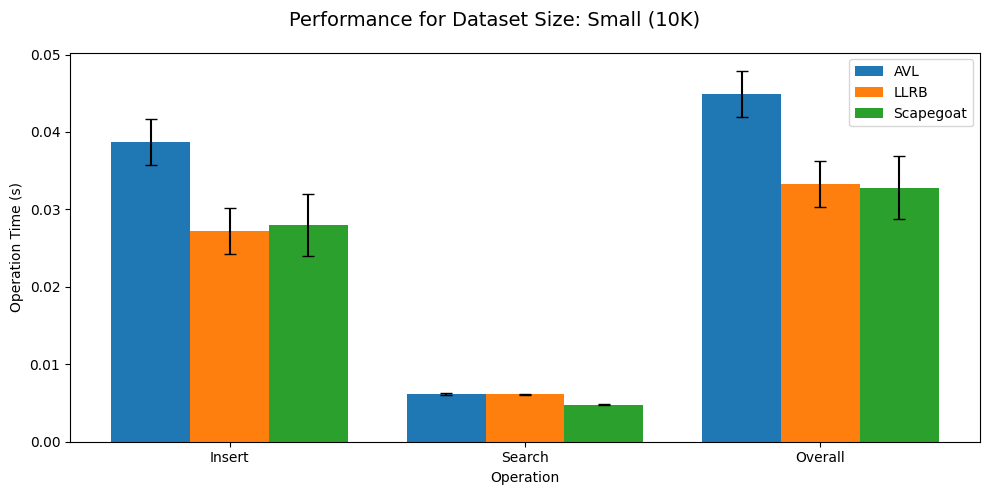

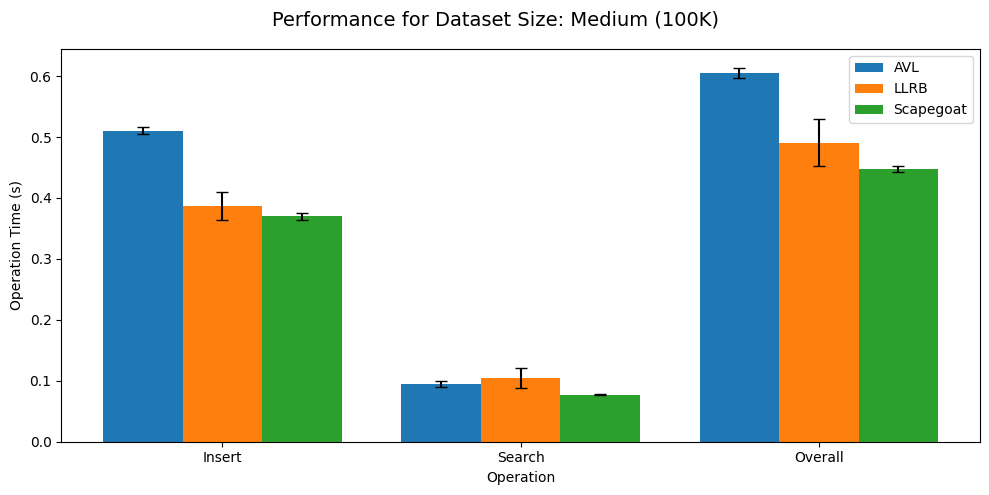

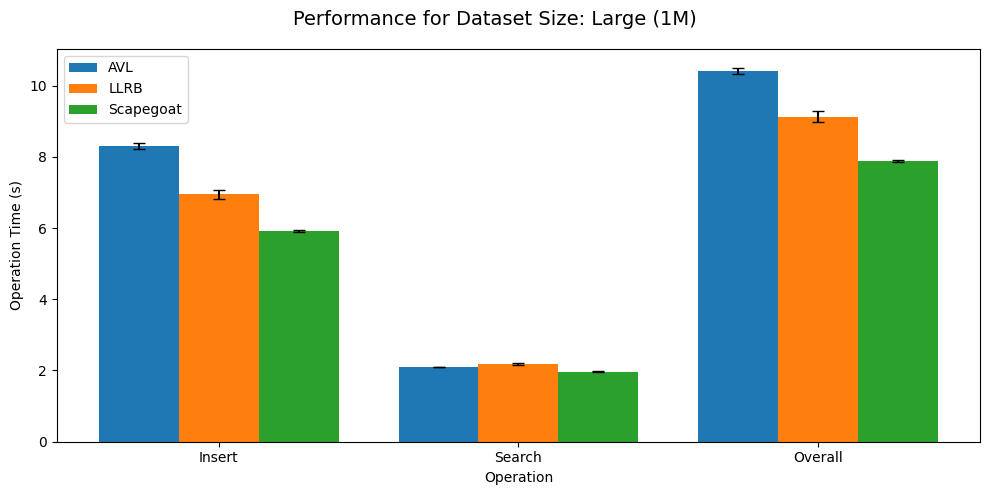

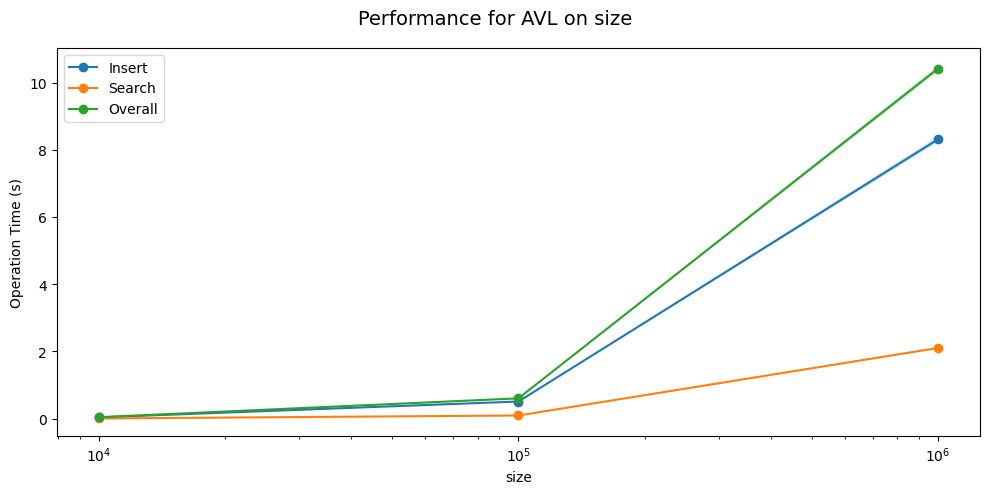

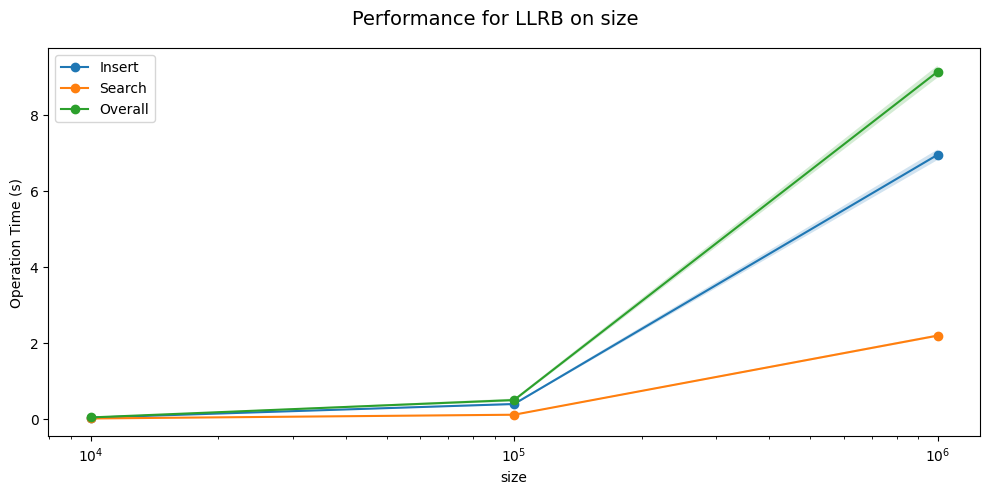

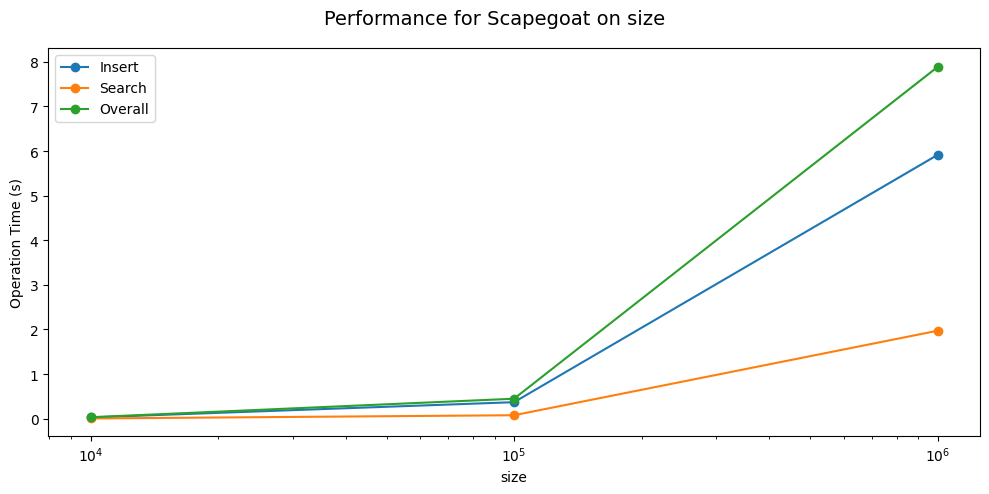

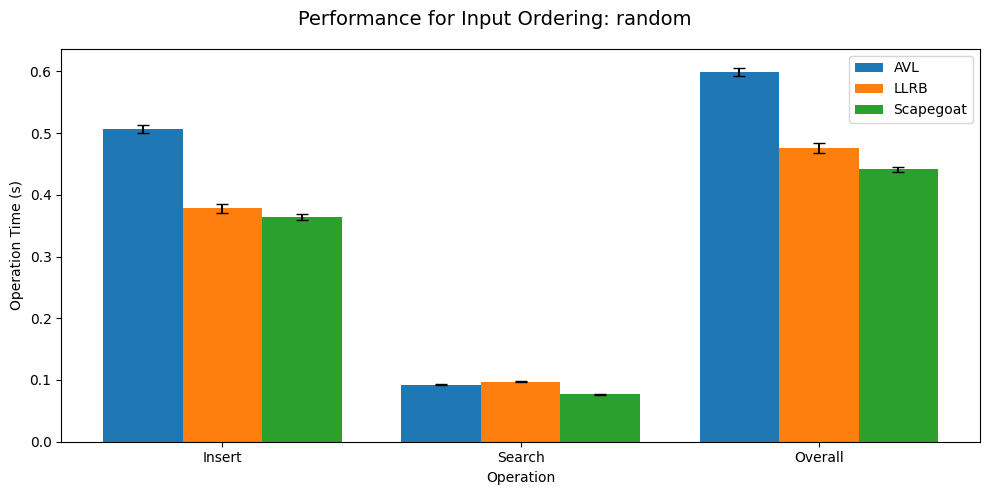

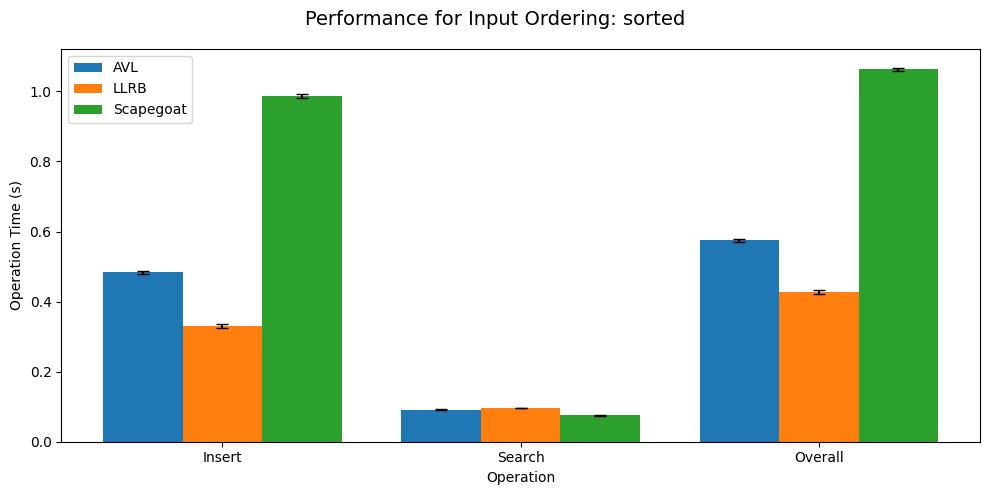

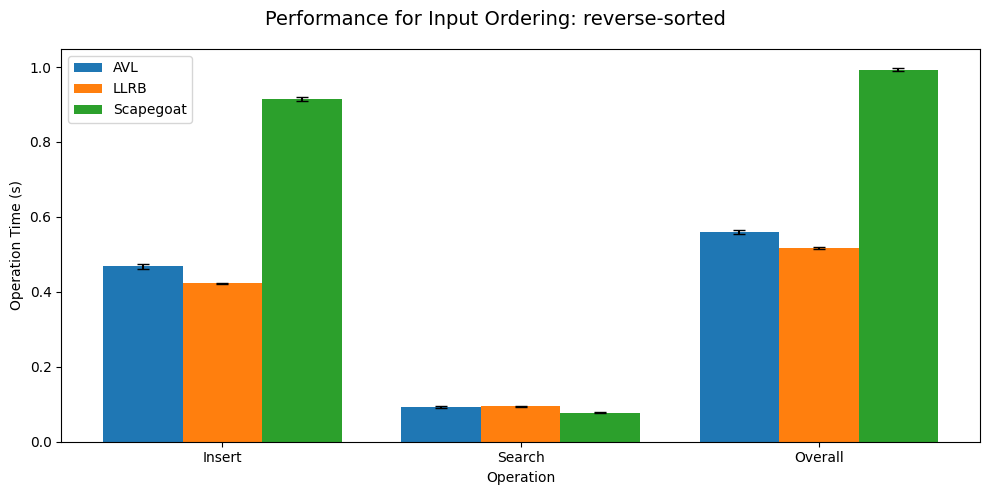

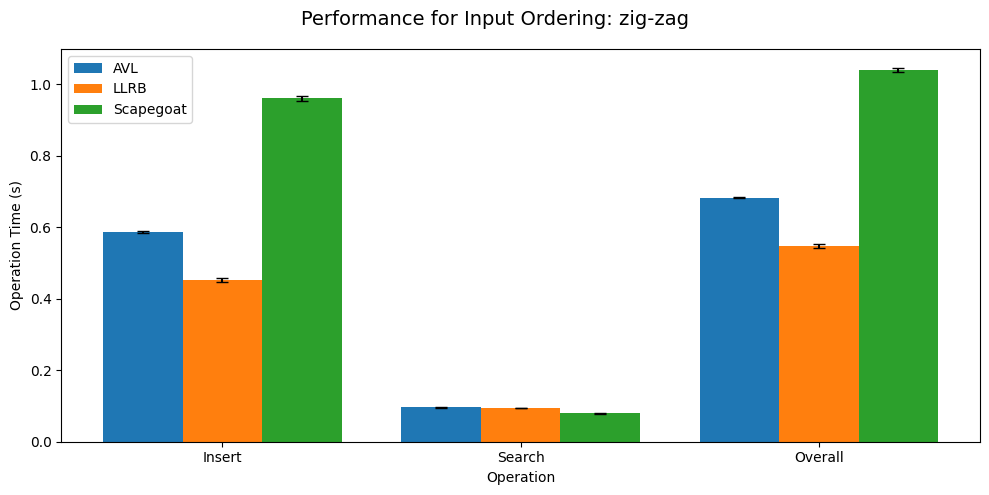

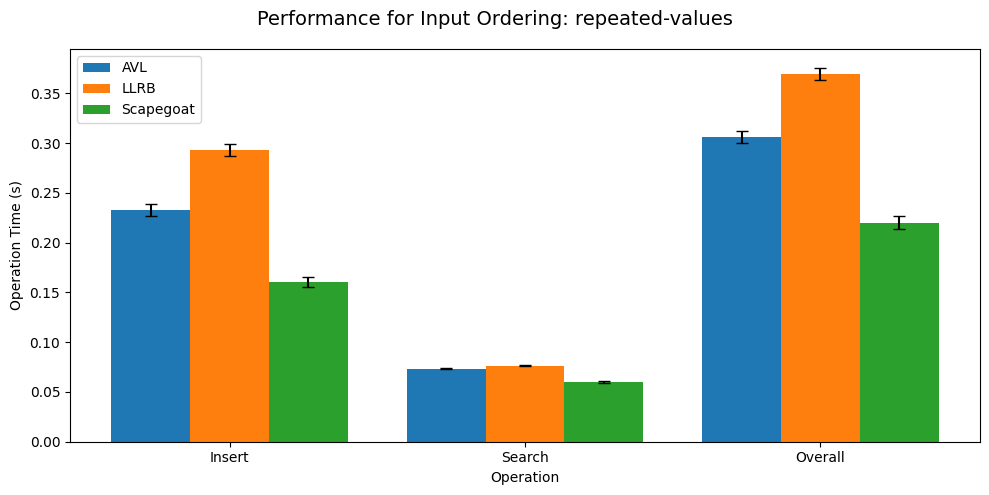

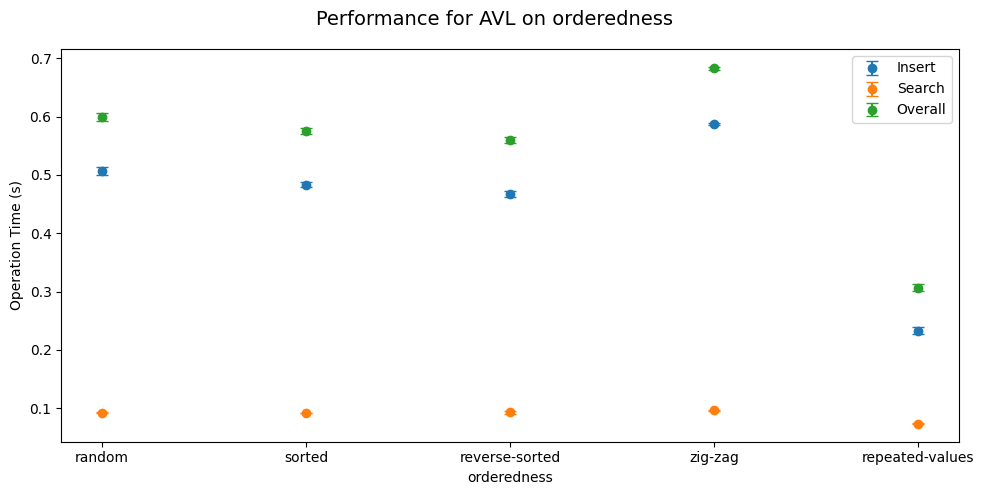

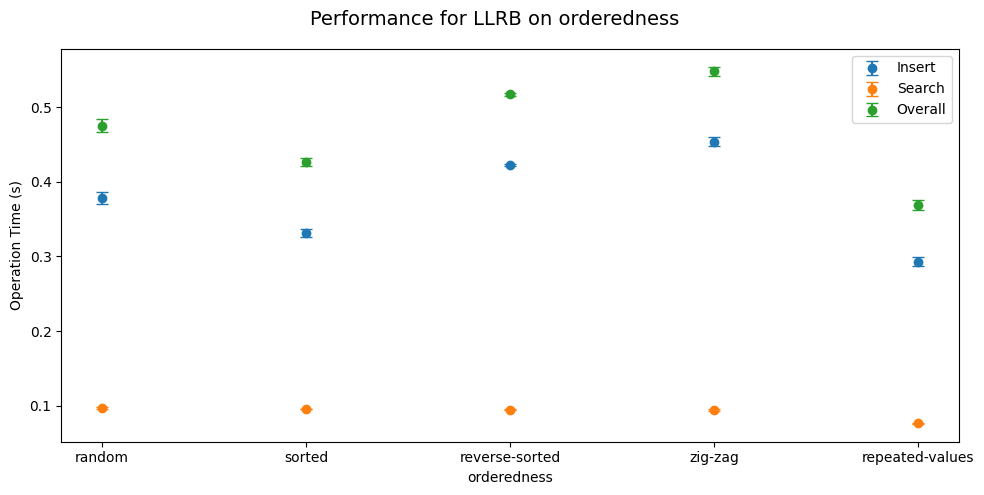

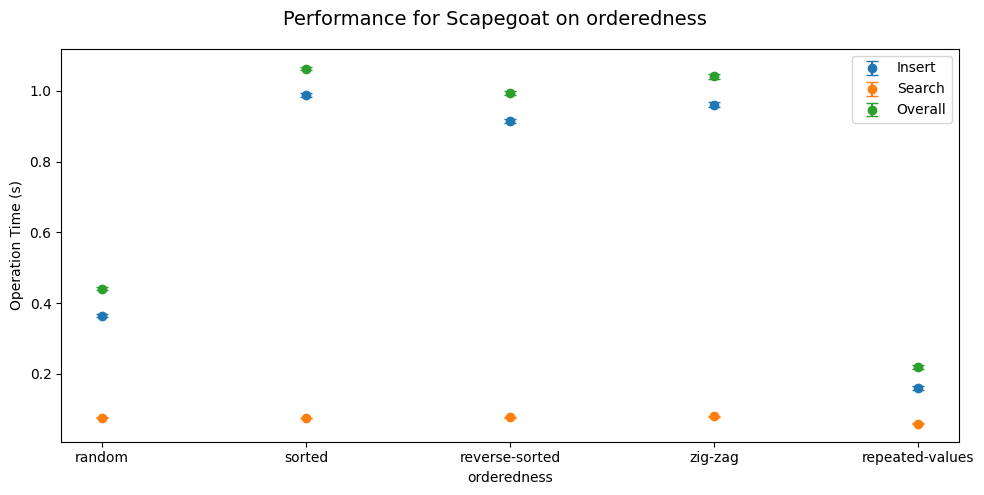

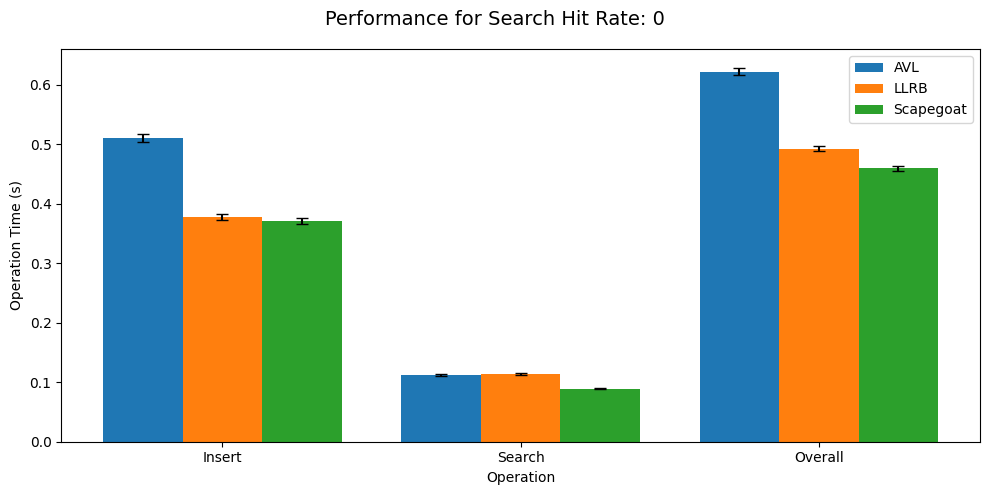

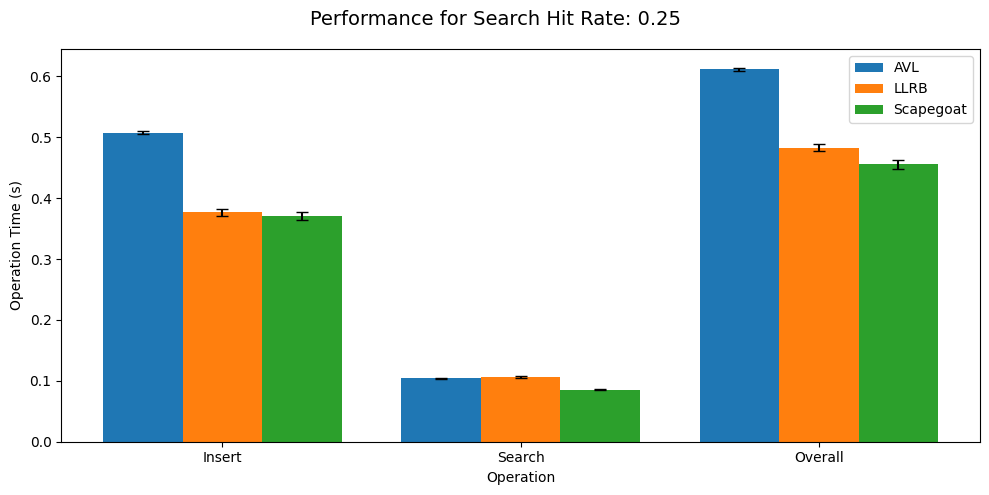

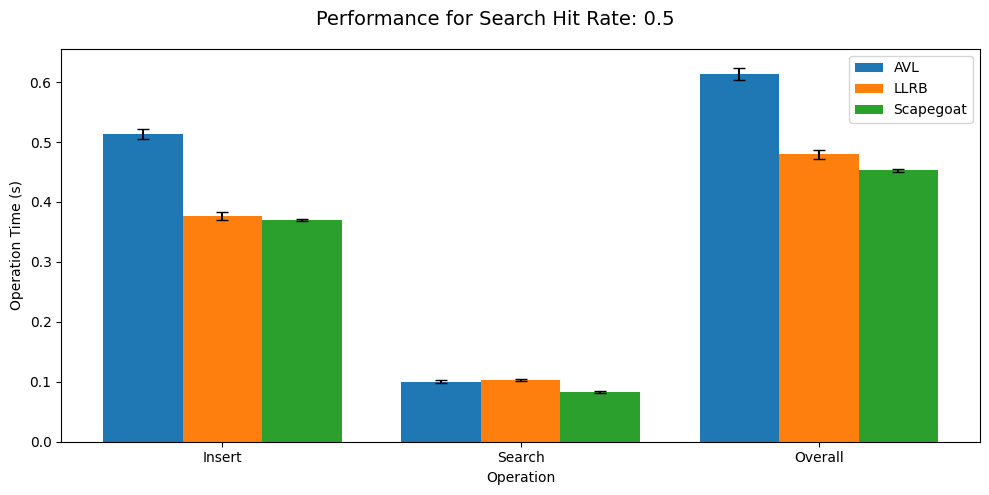

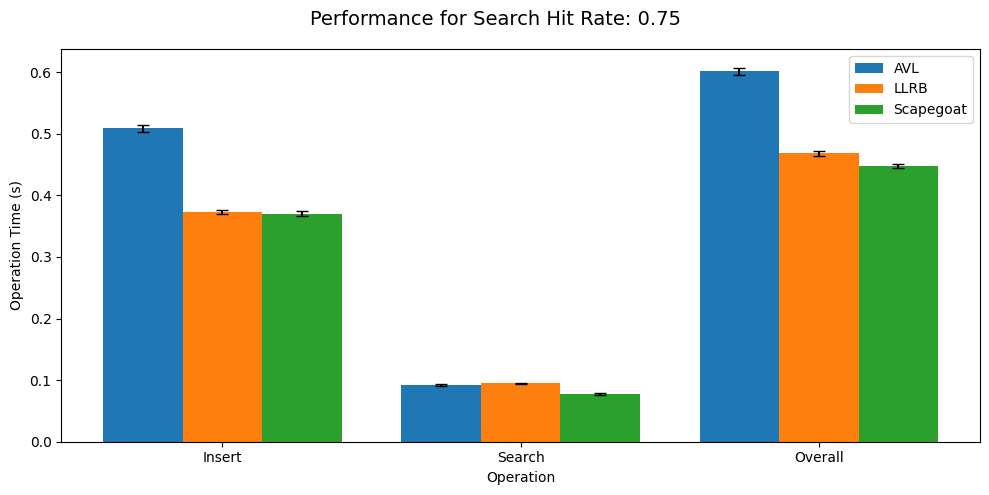

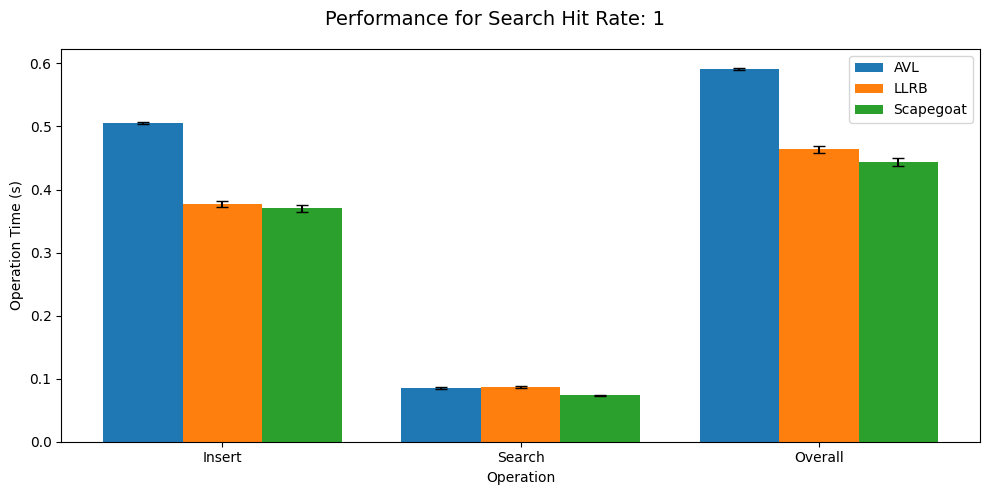

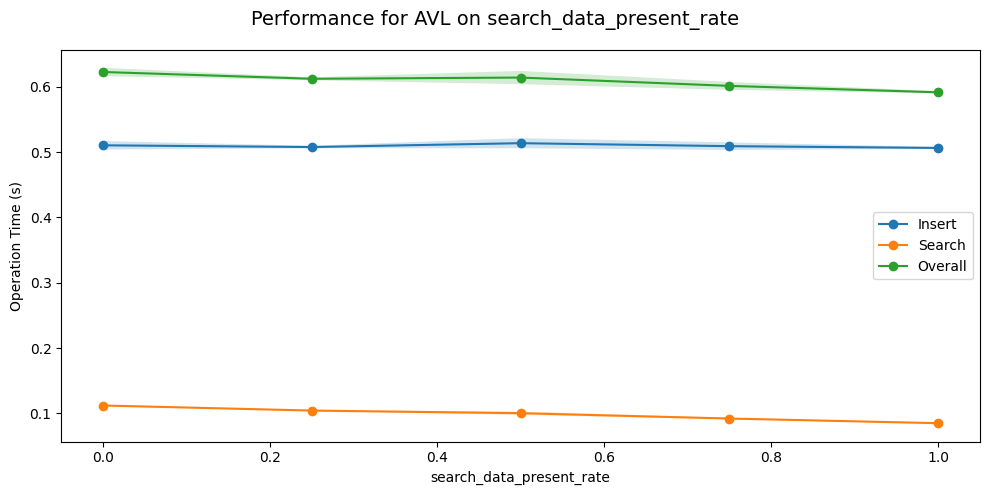

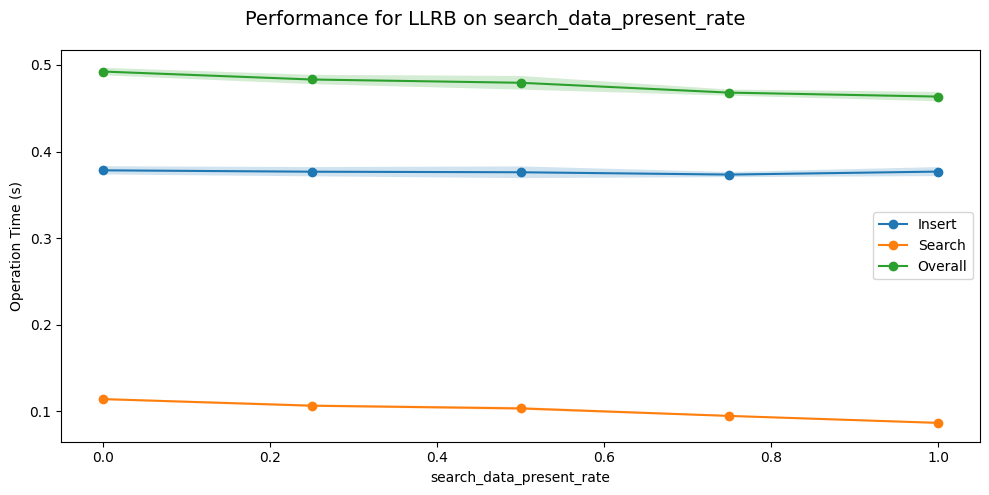

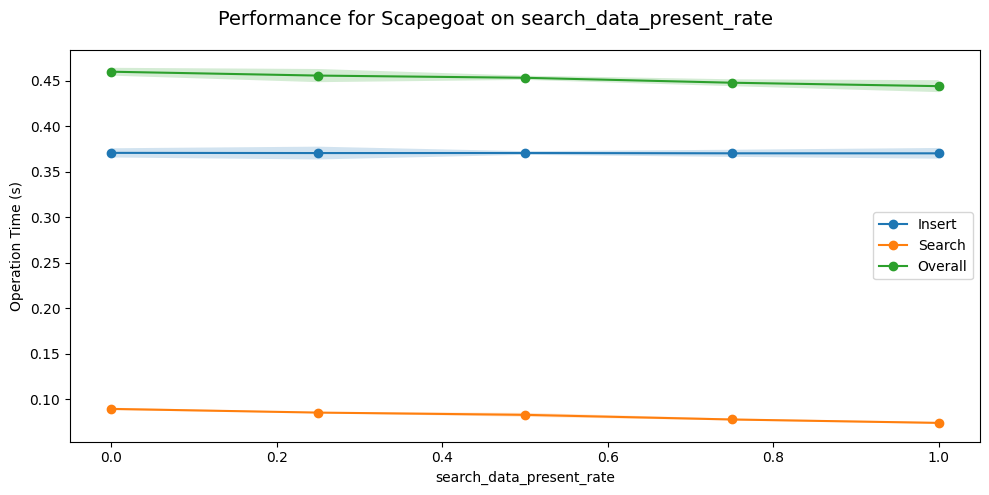

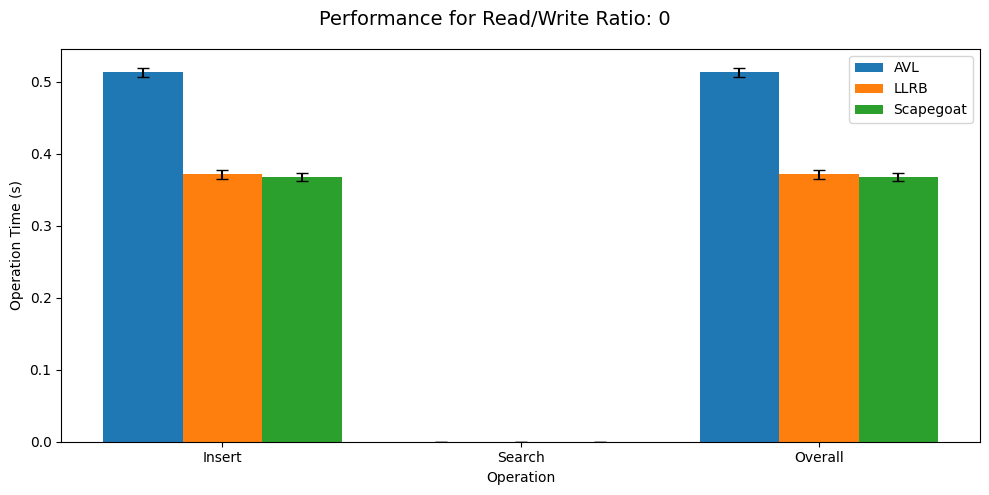

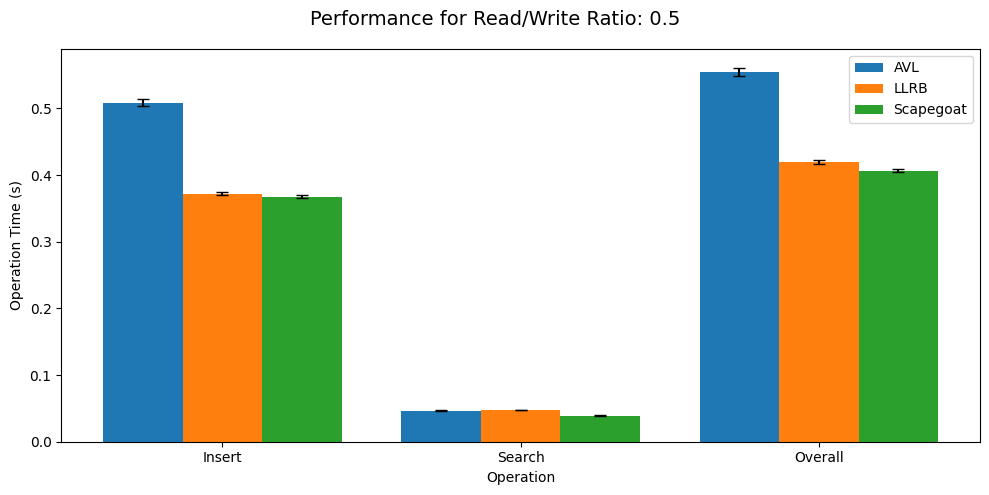

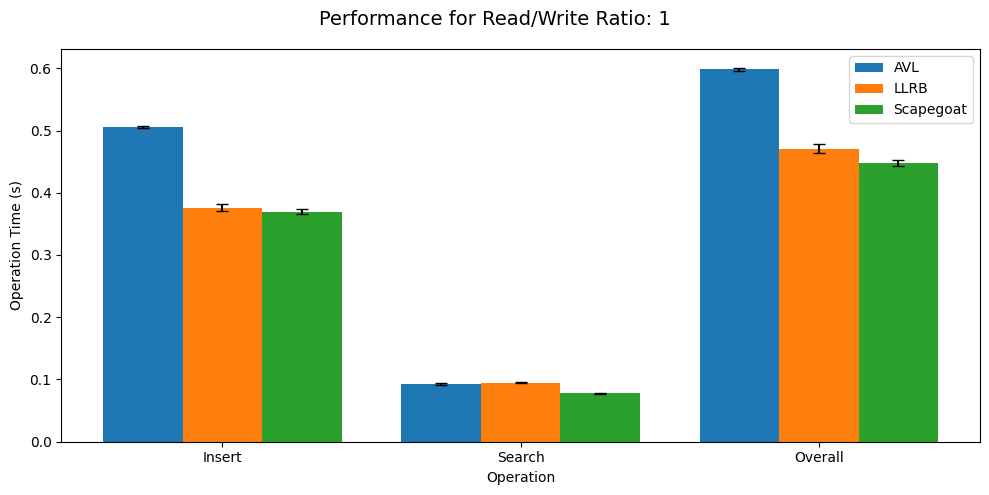

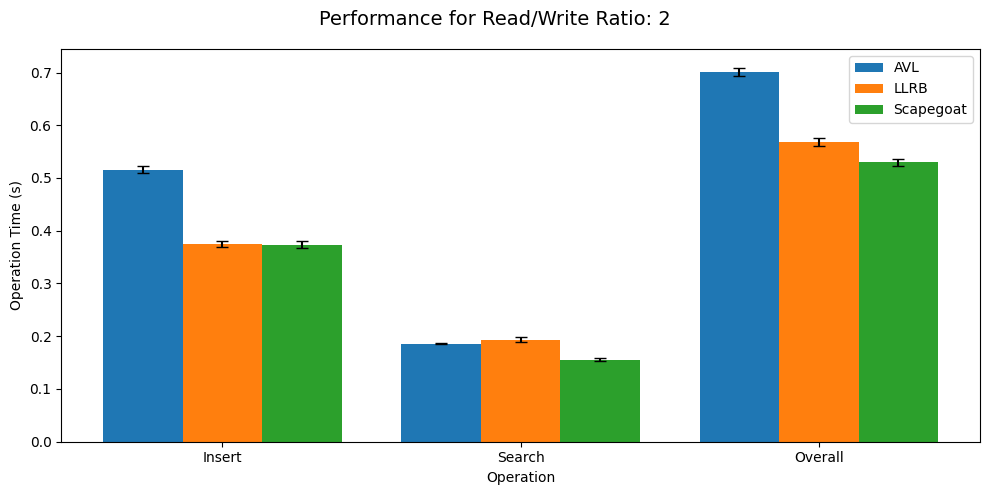

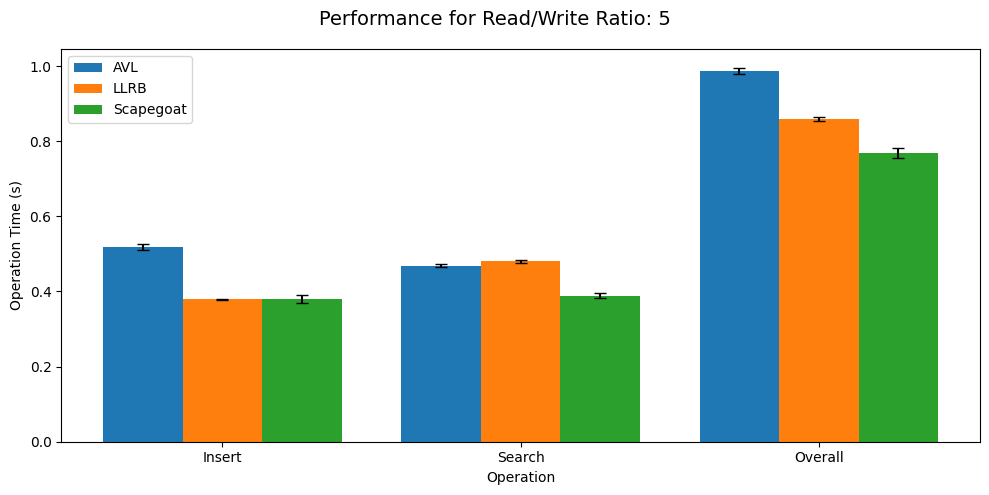

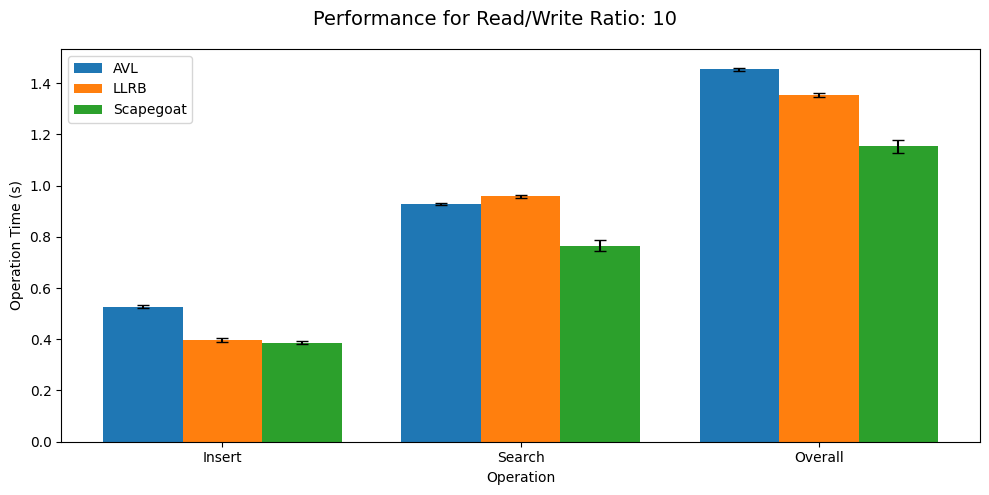

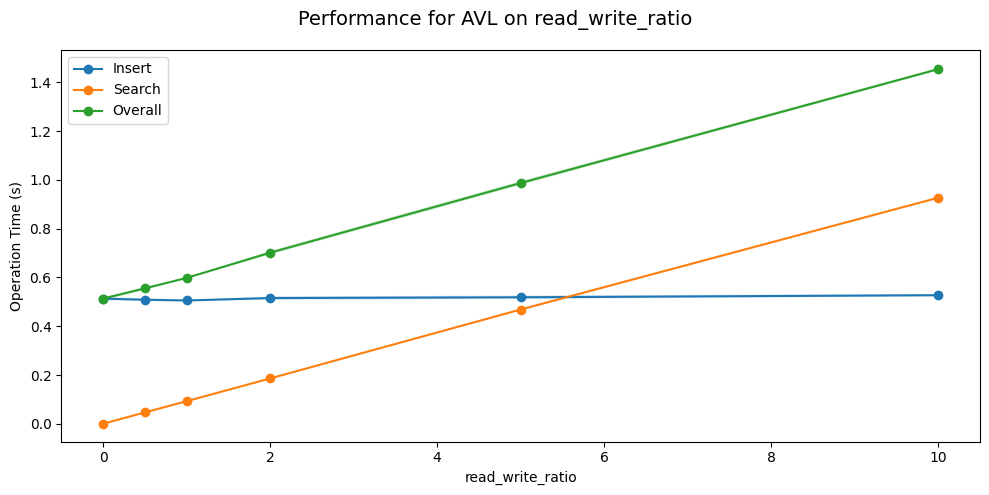

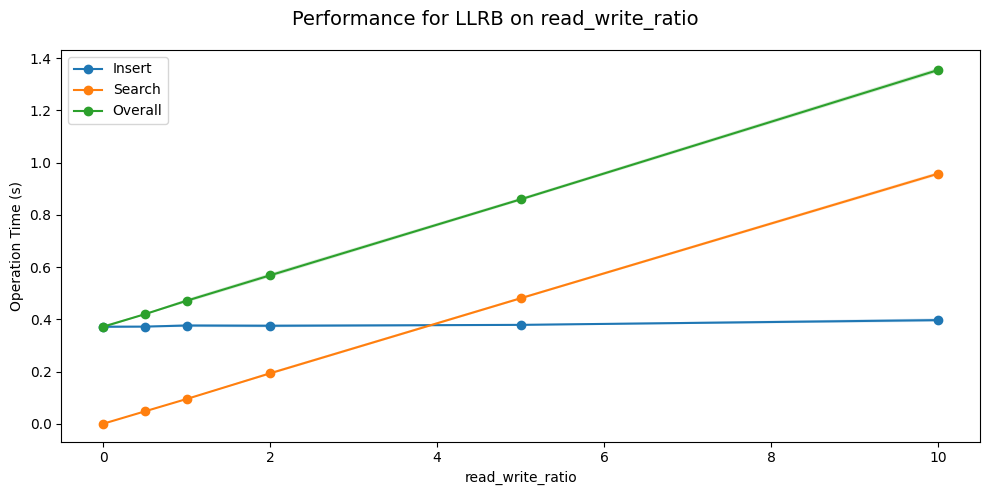

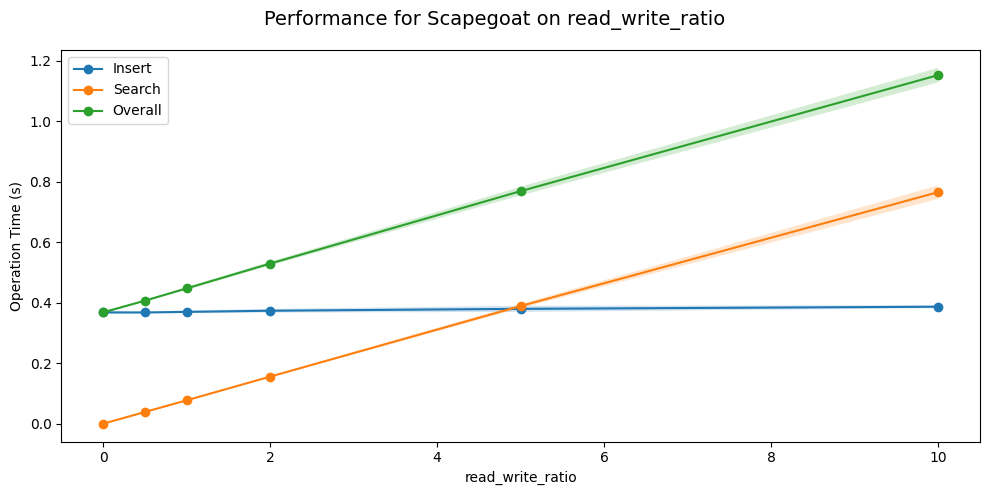


SUMMARY TABLE
Tree         Varied Param                 Value              Insert (s)        ±95% CI          Search (s)        ±95% CI          Overall (s)       ±95% CI         
------------------------------------------------------------------------------------------------------------------------------------------------------
LLRB         size                         Small (10K)        0.027207          ±    0.002949 0.006106      ±    0.000092 0.033313      ±    0.003000
LLRB         size                         Medium (100K)      0.386377          ±    0.023165 0.104689      ±    0.016105 0.491065      ±    0.038746
LLRB         size                         Large (1M)         6.943202          ±    0.138493 2.185711      ±    0.031422 9.128913      ±    0.157553
LLRB         orderedness                  random             0.378129          ±    0.007615 0.097339      ±    0.001215 0.475467      ±    0.008264
LLRB         orderedness                  sorted             0.331121   

In [10]:
# Define the three tree implementations to evaluate
trees = {
    "LLRB": LLRBBST,
    "AVL": AVLTree,
    "Scapegoat": ScapegoatTree
}

# Create the framework and run the full evaluation (10 trials per configuration)
fw = ExperimentalFramework()
all_results = fw.run_full_evaluation(trees, num_trials=10)

# Plot all charts
fw.plot_full_evaluation(all_results)

# Print a summary table to stdout
print("\n" + "=" * 150)
print("SUMMARY TABLE")
print("=" * 150)
print(f"{'Tree':<12} {'Varied Param':<28} {'Value':<18} {'Insert (s)':<18}{'±95% CI':<16} {'Search (s)':<18}{'±95% CI':<16} {'Overall (s)':<18}{'±95% CI':<16}")
print("-" * 150)

for r in all_results:
    tree_name = r["tree_name"]
    param = r["varied_parameter"]
    value = r[param]

    if param == "size":
        display_value = fw.SIZE_LABELS.get(value, str(value))
    else:
        display_value = str(value)

    insert_time = r["mean_insert_time"]
    search_time = r["mean_search_time"]
    overall_time = r["mean_overall_time"]
    search_time = r["mean_search_time"]

    num_trials = r["num_trials"]
    critical_z = 2.262 # as above

    insert_CI = r["sd_insert_time"] * critical_z / num_trials**0.5
    search_CI = r["sd_search_time"] * critical_z / num_trials**0.5
    overall_CI = r["sd_overall_time"] * critical_z / num_trials**0.5

    print(f"{tree_name:<12} {param:<28} {display_value:<18} {insert_time:<18.6f}{f'±{insert_CI:12.6f}'} {search_time:<14.6f}{f'±{search_CI:12.6f}'} {overall_time:<14.6f}{f'±{overall_CI:12.6f}'}")

print("=" * 150)
